## Diabetes Classification using machine learning model ##

Author Name : Muhammad Subhan  
Project : Diabetes classification  





## Overview
This dataset is originally from the **National Institute of Diabetes and Digestive and Kidney Diseases**. The main objective of the dataset is to predict whether a patient has diabetes based on several diagnostic measurements.

Certain constraints were applied while selecting the data from a larger database:

- All patients are **female**
- Patients are at least **21 years old**
- All patients belong to **Pima Indian heritage**

The dataset is commonly used for **machine learning classification problems** where the target variable is **Outcome**.

---

# Dataset Attributes

| Attribute | Description |
|-----------|-------------|
| **Pregnancies** | Number of times the patient has been pregnant |
| **Glucose** | Glucose concentration level in blood |
| **BloodPressure** | Blood pressure measurement |
| **SkinThickness** | Thickness of the skin fold |
| **Insulin** | Insulin level in blood |
| **BMI** | Body Mass Index, used to measure body fat based on height and weight |
| **DiabetesPedigreeFunction** | Indicates the likelihood of diabetes based on family history |
| **Age** | Age of the patient |
| **Outcome** | Diabetes test result: `1` = Diabetic, `0` = Non-diabetic |

---

# Dataset Type

## Independent Variables (Features)
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age

## Dependent Variable (Target)
- Outcome

---

# Purpose of the Dataset

The dataset is mainly used for:

- Predictive analytics
- Machine learning classification
- Medical diagnosis research
- Diabetes prediction systems

---

# Example of Prediction

The model uses the medical attributes to predict:

- `Outcome = 1` → Patient has diabetes
- `Outcome = 0` → Patient does not have diabetes

## Importing the Libraries ##

In [182]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Loading the Dataset ##

In [183]:
df = pd.read_csv(r'C:\Users\User\Desktop\Machine Learning\diabetes.csv')

In [184]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [185]:
rows,columns = df.shape
print(f' rows are {rows} columns are {columns}')

 rows are 768 columns are 9


In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [187]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [188]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [189]:
percentage_missing_values = df.isnull().sum()/len(df)*100
print(percentage_missing_values)

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64


In [190]:
number_duplicates = df.duplicated().sum()
print(number_duplicates)

0


In [191]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Exploratory Data Analysis ###

Q1 : What is the average glucose level of patients?

In [192]:
print(f"average glucose level of patient is {df['Glucose'].mean()}")

average glucose level of patient is 120.89453125


Q2 : How many patients have diabetes (Outcome = 1)?

In [193]:
patient_diabetes = df[df['Outcome'] == 1].count()
print(f' there are {patient_diabetes[1]} patient that have diabetes')

 there are 268 patient that have diabetes


C:\Users\User\AppData\Local\Temp\ipykernel_25616\254981904.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f' there are {patient_diabetes[1]} patient that have diabetes')


In [194]:
patient_diabetes = df[df['Outcome'] == 0].count()
print(f' there are {patient_diabetes[1]} patient that have no  diabetes')

 there are 500 patient that have no  diabetes


C:\Users\User\AppData\Local\Temp\ipykernel_25616\876643459.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f' there are {patient_diabetes[1]} patient that have no  diabetes')


Q3 :What is the maximum number of pregnancies recorded in the dataset?

In [195]:
maximun_pregnancies = df['Pregnancies'].max()
print(f'Maximun number of pregnancies is {maximun_pregnancies}')

Maximun number of pregnancies is 17


Q4 : Is high glucose level related to diabetes?

In [196]:
high_glucose_diabetes = df.groupby('Outcome')['Glucose'].mean().sort_values(ascending=False)
print(f' average glucose level for Diabetes and no diabetes{high_glucose_diabetes}')

 average glucose level for Diabetes and no diabetesOutcome
1    141.257463
0    109.980000
Name: Glucose, dtype: float64


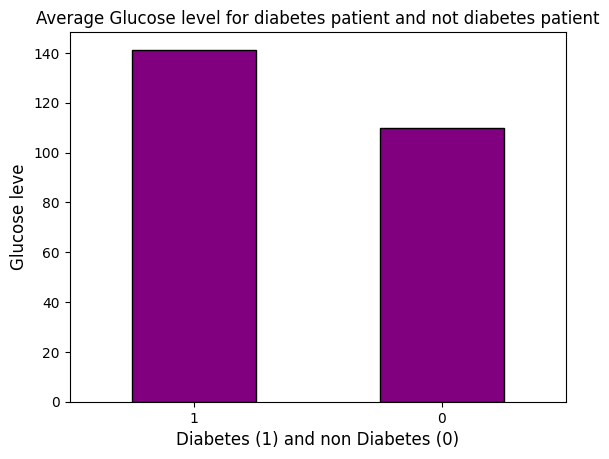

In [197]:
high_glucose_diabetes.plot(kind='bar',color='purple',edgecolor='black')
plt.xlabel('Diabetes (1) and non Diabetes (0)',fontsize =12)
plt.ylabel('Glucose leve',fontsize =12)
plt.title('Average Glucose level for diabetes patient and not diabetes patient')
plt.xticks(rotation=360)
plt.show()

Outcome is : When glucose level is increasing the patient has higher chance of Diabetes

Q5 : Which feature has the strongest correlation with the Outcome?

In [198]:
correlation = df.corr(numeric_only=True)

# Correlation with Outcome
outcome_corr = correlation['Outcome'].sort_values(ascending=False)

print(outcome_corr)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


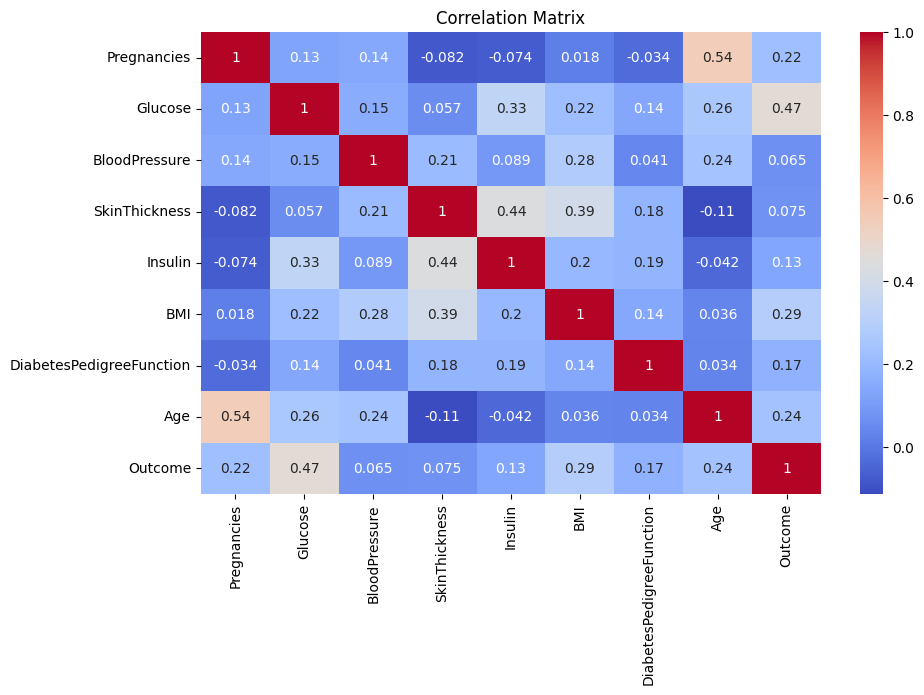

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [200]:
strongest_feature = outcome_corr.drop('Outcome').idxmax()
strongest_value = outcome_corr.drop('Outcome').max()

print("Strongest feature:", strongest_feature)
print("Correlation:", strongest_value)

Strongest feature: Glucose
Correlation: 0.46658139830687373


Age VS Diabetes

In [201]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Feature Engeenering

In [202]:
bins = [20,35,55,82]
labels = ["Younger girls","Women","Older Women"]

df['Age_category'] = pd.cut(df['Age'],bins=bins,labels=labels)

In [203]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_category
0,6,148,72,35,0,33.6,0.627,50,1,Women
1,1,85,66,29,0,26.6,0.351,31,0,Younger girls
2,8,183,64,0,0,23.3,0.672,32,1,Younger girls
3,1,89,66,23,94,28.1,0.167,21,0,Younger girls
4,0,137,40,35,168,43.1,2.288,33,1,Younger girls


In [204]:
average_Age_outcome = df.groupby('Age_category')['Outcome'].mean().sort_values(ascending=False)
average_Age_outcome

C:\Users\User\AppData\Local\Temp\ipykernel_25616\3122780464.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_Age_outcome = df.groupby('Age_category')['Outcome'].mean().sort_values(ascending=False)


Age_category
Women            0.545455
Older Women      0.340000
Younger girls    0.263052
Name: Outcome, dtype: float64

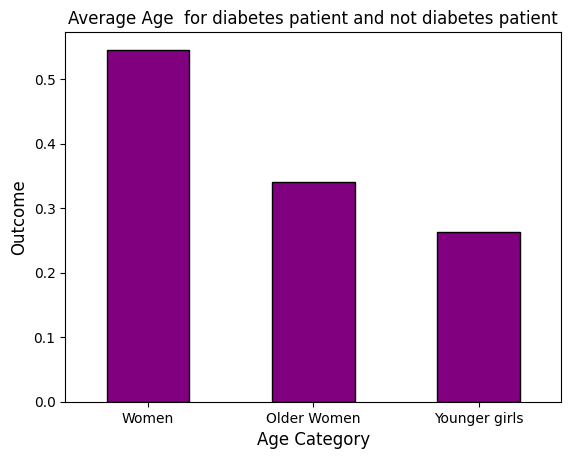

In [205]:
average_Age_outcome.plot(kind='bar',color='purple',edgecolor='black')
plt.xlabel('Age Category',fontsize =12)
plt.ylabel('Outcome',fontsize =12)
plt.title('Average Age  for diabetes patient and not diabetes patient')
plt.xticks(rotation=360)
plt.show()

Women patient   with the age of 35 to 55 have higher diabeteschances 

Distribution of Age

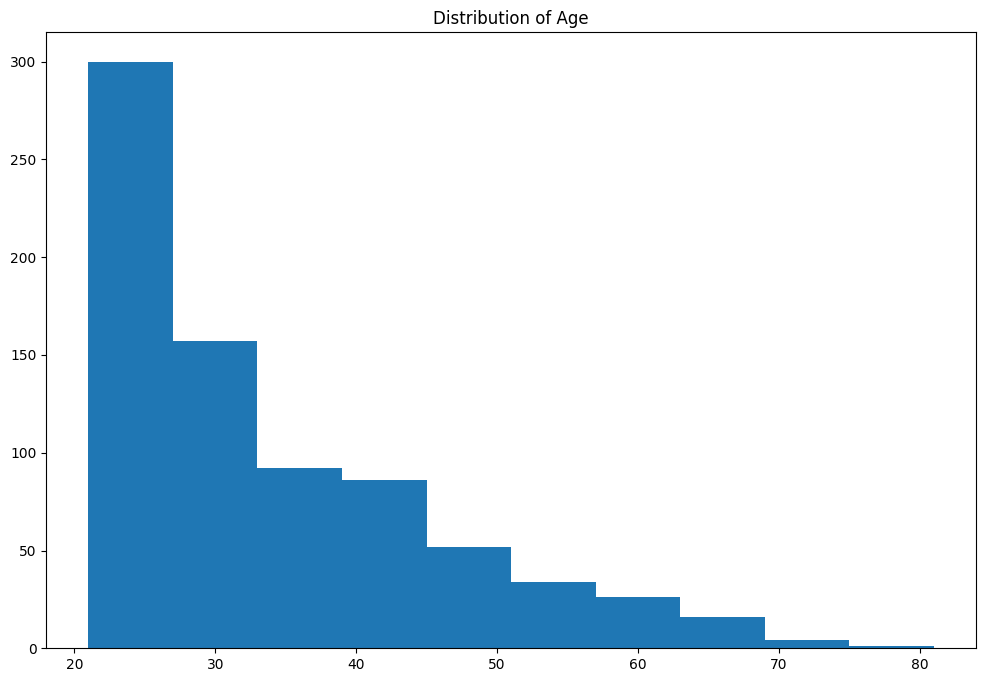

In [206]:
plt.figure(figsize=(12,8))
plt.hist(df['Age'],bins=10)
plt.title('Distribution of Age',fontsize=12)
plt.show()

LabelEncoding

In [207]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[["Younger girls","Women","Older Women"]])
df['Encoded Age'] = encoder.fit_transform(df[['Age_category']])


Scaling

In [208]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Outcome','Age_category']) 
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Building the Model ##

In [209]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)



In [210]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression()

logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [211]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = logistic_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.73

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       151
           1       0.62      0.60      0.61        80

    accuracy                           0.73       231
   macro avg       0.70      0.70      0.70       231
weighted avg       0.73      0.73      0.73       231


Confusion Matrix:
[[121  30]
 [ 32  48]]


In [212]:
from sklearn.neighbors import KNeighborsClassifier

k_model = KNeighborsClassifier(n_neighbors=5)

k_model.fit(X_train, y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [213]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = k_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.69

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.81      0.77       151
           1       0.57      0.47      0.52        80

    accuracy                           0.69       231
   macro avg       0.66      0.64      0.65       231
weighted avg       0.68      0.69      0.69       231


Confusion Matrix:
[[122  29]
 [ 42  38]]


In [214]:
from sklearn.tree import DecisionTreeClassifier

decision_model = DecisionTreeClassifier()

decision_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [215]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = decision_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.72

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.73      0.77       151
           1       0.58      0.70      0.63        80

    accuracy                           0.72       231
   macro avg       0.70      0.71      0.70       231
weighted avg       0.74      0.72      0.72       231


Confusion Matrix:
[[110  41]
 [ 24  56]]


In [218]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [219]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.73

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       151
           1       0.60      0.65      0.62        80

    accuracy                           0.73       231
   macro avg       0.70      0.71      0.70       231
weighted avg       0.73      0.73      0.73       231


Confusion Matrix:
[[116  35]
 [ 28  52]]


### Making The Predictions from model ###

In [226]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def model_predictions(input_data):
    scalar = StandardScaler()
    input_data = scalar.fit_transform(input_data)
    prediction = rf.predict(input_data)
    if prediction[0] == 1:
        print("You are diabetes Patient")
    else:
        print(" You are not a  diabetes patient")



pregnancies = int(input('Enter the number of pregnancies'))
glucose = int(input('Enter the Glucose level in your blood'))
blood_pressure = int(input('Enter your blood pressure'))
skin_thickness = int(input('what is your skin Thickness'))
insulin_level = int(input('Enter the Insulin level in your blood'))
bmi = float(input('Enter you Body mass index'))
Diabetes_Pedigree = float(input('Enter Diabetes Pedigree'))

Age = int(input('Enter your age (Age must be above or equal to 21 years )'))
Age_category = float(input('Enter your Age Category \n Press 1 if you are women \n press 0 if you are a Younger Girl \n press 2 if you are Older women'))

input_data = [[pregnancies,glucose,blood_pressure,skin_thickness,insulin_level,bmi,Diabetes_Pedigree,Age,Age_category]]

model_predictions(input_data)

 You are not a  diabetes patient


In [225]:
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Age_category,Encoded Age
0,6,148,72,35,0,33.6,0.627,50,1,Women,1.0
1,1,85,66,29,0,26.6,0.351,31,0,Younger girls,0.0
2,8,183,64,0,0,23.3,0.672,32,1,Younger girls,0.0
3,1,89,66,23,94,28.1,0.167,21,0,Younger girls,0.0
4,0,137,40,35,168,43.1,2.288,33,1,Younger girls,0.0
5,5,116,74,0,0,25.6,0.201,30,0,Younger girls,0.0
6,3,78,50,32,88,31.0,0.248,26,1,Younger girls,0.0
7,10,115,0,0,0,35.3,0.134,29,0,Younger girls,0.0
8,2,197,70,45,543,30.5,0.158,53,1,Women,1.0
9,8,125,96,0,0,0.0,0.232,54,1,Women,1.0
